### Постановка задачи классификации SI  > median
Цель: предсказать, превышает ли значение `SI ` медианное значение по выборке.
Будут протестированы 3 модели: Random Forest, Gradient Boosting и SVM на данных с выбросами и без них.

In [1]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.4 MB/s eta 0:00:00


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Модели и метрики
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score, cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, mean_squared_error, r2_score, root_mean_squared_error,  roc_auc_score
)

# Сторонние библиотеки для градиентного бустинга и оптимизации
import xgboost as xgb
import lightgbm as lgb
import optuna

In [3]:
file_path = '/content/cleaned_molecular_data.csv'
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
display(df.head())
print(df.info())

Dataset Shape: (966, 214)


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,is_outlier
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,3,0,1
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,3,0,1
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,3,0,1
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,4,0,1
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Columns: 214 entries, IC50, mM to is_outlier
dtypes: float64(107), int64(107)
memory usage: 1.6 MB
None


In [19]:
# 1. Подготовка меток (классификация по медиане)
median_SI = df['SI'].median()
df['target_class'] = (df['SI'] > median_SI).astype(int)

# 2. Подготовка выборок
# А) С выбросами
X_with = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI', 'is_outlier', 'target_class'])
y_with = df['target_class']

# Б) Без выбросов
df_no_outliers = df[df['is_outlier'] == 1].copy()
X_no = df_no_outliers.drop(columns=['IC50, mM', 'CC50, mM', 'SI', 'is_outlier', 'target_class'])
y_no = df_no_outliers['target_class']

print(f"Медиана SI: {median_SI:.4f}")

Медиана SI: 3.9134


In [20]:
y_with.value_counts()

,count
target_class,
1,483
0,483


In [21]:
# классы сбалансированны

In [64]:
def evaluate_models(X, y, title):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Масштабирование (важно для SVM)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
        'SVM': SVC(random_state=42)
    }

    results = []
    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        pred_tr= model.predict(X_train_scaled)
        acc = accuracy_score(y_test, preds)
        acc_tr = accuracy_score(y_train, pred_tr)
        f1_tr = f1_score(y_train, pred_tr)
        f1 = f1_score(y_test, preds)
        results.append({'Model': name, 'Accuracy': acc, 'Accuracy_train': acc_tr, 'F1': f1, 'F1_train': f1_tr})

    res_df = pd.DataFrame(results)
    print(f"\nРезультаты для: {title}")
    display(res_df)
    return res_df

results_with = evaluate_models(X_with, y_with, "Данные С ВЫБРОСАМИ")
results_no = evaluate_models(X_no, y_no, "Данные БЕЗ ВЫБРОСОВ")


Результаты для: Данные С ВЫБРОСАМИ


,Model,Accuracy,Accuracy_train,F1,F1_train
0,Random Forest,0.644330,0.955959,0.634921,0.956743
1,Gradient Boosting,0.664948,0.905440,0.663212,0.907006
2,SVM,0.721649,0.770725,0.709677,0.761134



Результаты для: Данные БЕЗ ВЫБРОСОВ


,Model,Accuracy,Accuracy_train,F1,F1_train
0,Random Forest,0.663043,0.953615,0.635294,0.954424
1,Gradient Boosting,0.673913,0.904502,0.638554,0.905914
2,SVM,0.684783,0.789905,0.618421,0.785515


In [65]:
X_train, X_test, y_train, y_test = train_test_split(X_with, y_with, test_size=0.2, random_state=42, stratify=y_with)

In [61]:
def objective_svm_cls(trial):
    params = {
        'C': trial.suggest_float('C',0.9,1.1,log=True),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf', 'sigmoid']),
        'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
        'random_state': 42,
        'probability': True
    }
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = SVC(**params)
    model.fit(X_train_scaled, y_train)

    train_p = model.predict(X_train_scaled)
    test_p = model.predict(X_test_scaled)

    test_f1 = f1_score(y_test, test_p)
    train_f1 = f1_score(y_train, train_p)

    gap = abs(train_f1 - test_f1)
    penalty_factor = 0.6

    return train_f1 - penalty_factor * gap

study_svm_cls = optuna.create_study(direction='maximize')
study_svm_cls.optimize(objective_svm_cls, n_trials=200)

print("Best SVM Parameters:", study_svm_cls.best_params)
print("Best Penalized F1 Score:", study_svm_cls.best_value)

[I 2026-05-23 22:23:20,250] A new study created in memory with name: no-name-5b352e31-5883-4a06-b04b-9ab65b8909ec
[I 2026-05-23 22:23:20,739] Trial 0 finished with value: 0.7168990428691921 and parameters: {'C': 1.0515774656225203, 'kernel': 'rbf', 'gamma': 'auto'}. Best is trial 0 with value: 0.7168990428691921.
[I 2026-05-23 22:23:22,789] Trial 1 finished with value: 0.7060590562838147 and parameters: {'C': 1.065871523352704, 'kernel': 'linear', 'gamma': 'scale'}. Best is trial 0 with value: 0.7168990428691921.
[I 2026-05-23 22:23:23,282] Trial 2 finished with value: 0.7309277454134423 and parameters: {'C': 1.025631194576366, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 2 with value: 0.7309277454134423.
[I 2026-05-23 22:23:25,728] Trial 3 finished with value: 0.7036245110821382 and parameters: {'C': 0.9542413592344219, 'kernel': 'linear', 'gamma': 'scale'}. Best is trial 2 with value: 0.7309277454134423.
[I 2026-05-23 22:23:26,522] Trial 4 finished with value: 0.7279828530602525

Best SVM Parameters: {'C': 1.0579835926785617, 'kernel': 'rbf', 'gamma': 'scale'}
Best Penalized F1 Score: 0.7322580645161291


Optimized SVM Performance:
Train Accuracy: 0.7746 | Test Accuracy: 0.7216
Train F1-Score: 0.7661 | Test F1-Score: 0.7097
ROC AUC:   0.7725

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.70      0.76      0.73        97
           1       0.74      0.68      0.71        97

    accuracy                           0.72       194
   macro avg       0.72      0.72      0.72       194
weighted avg       0.72      0.72      0.72       194



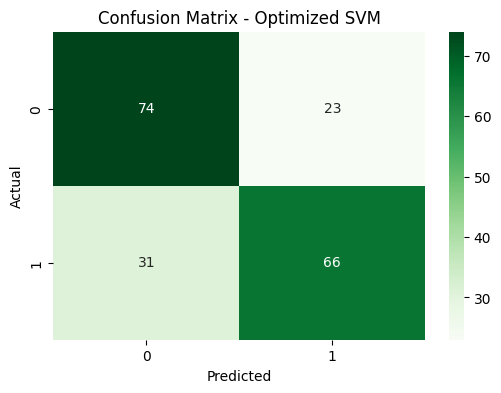

In [74]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_svm_cls = SVC(**study_svm_cls.best_params, random_state=42, probability=True)
best_svm_cls.fit(X_train_scaled, y_train)

# Предсказания
train_preds = best_svm_cls.predict(X_train_scaled)
final_preds = best_svm_cls.predict(X_test_scaled)
final_probs = best_svm_cls.predict_proba(X_test_scaled)[:, 1]

# Метрики
acc_train = accuracy_score(y_train, train_preds)
f1_train = f1_score(y_train, train_preds)
acc_test = accuracy_score(y_test, final_preds)
f1_test = f1_score(y_test, final_preds)
roc_auc = roc_auc_score(y_test, final_probs)

print("Optimized SVM Performance:")
print(f"Train Accuracy: {acc_train:.4f} | Test Accuracy: {acc_test:.4f}")
print(f"Train F1-Score: {f1_train:.4f} | Test F1-Score: {f1_test:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, final_preds))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, final_preds), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Optimized SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [71]:
def objective_rf_cls(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 400),
        'max_depth': trial.suggest_int('max_depth', 2, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 15),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': 42
    }

    model = RandomForestClassifier(**params)

    model.fit(X_train, y_train)


    train_p = model.predict(X_train)
    test_p = model.predict(X_test)
    test_f1 = f1_score(y_test, test_p)
    train_f1 = f1_score(y_train, train_p)
    gap = abs(train_f1 - test_f1)
    penalty_factor = 2

    return train_f1 - penalty_factor * gap

study_rf_cls = optuna.create_study(direction='maximize')

default_params = {
    'n_estimators': 100,
    'max_depth': 15,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 'sqrt'
}
study_rf_cls.enqueue_trial(default_params)

study_rf_cls.optimize(objective_rf_cls, n_trials=100)

print("Best RF Parameters:", study_rf_cls.best_params)
print("Best Penalized F1 Score:", study_rf_cls.best_value)

[I 2026-05-23 23:47:31,501] A new study created in memory with name: no-name-183cdde7-f82a-42b1-8efa-71f460906c25
[I 2026-05-23 23:47:32,146] Trial 0 finished with value: 0.28378891935177397 and parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.28378891935177397.
[I 2026-05-23 23:47:33,149] Trial 1 finished with value: 0.4313759355210133 and parameters: {'n_estimators': 207, 'max_depth': 10, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.4313759355210133.
[I 2026-05-23 23:47:54,894] Trial 2 finished with value: 0.30512757805494406 and parameters: {'n_estimators': 382, 'max_depth': 17, 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': None}. Best is trial 1 with value: 0.4313759355210133.
[I 2026-05-23 23:47:56,809] Trial 3 finished with value: 0.486287129076576 and parameters: {'n_estimators': 389, 'max_depth': 14, 

Best RF Parameters: {'n_estimators': 66, 'max_depth': 2, 'min_samples_split': 7, 'min_samples_leaf': 14, 'max_features': None}
Best Penalized F1 Score: 0.6454908418098603


Optimized RF Performance:
Train Accuracy: 0.6904 | Test Accuracy: 0.7062
Train F1-Score: 0.6551 | Test F1-Score: 0.6503
ROC AUC:   0.7515

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.66      0.87      0.75        97
           1       0.80      0.55      0.65        97

    accuracy                           0.71       194
   macro avg       0.73      0.71      0.70       194
weighted avg       0.73      0.71      0.70       194



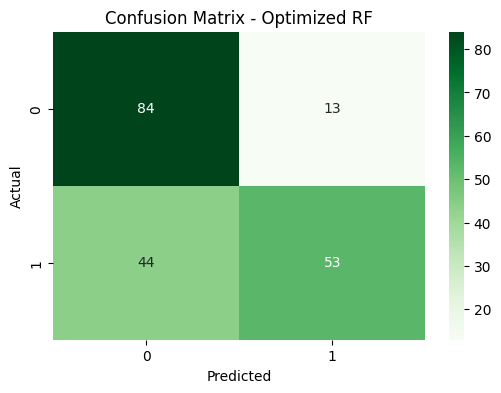

In [75]:
best_rf_cls = RandomForestClassifier(**study_rf_cls.best_params, random_state=42)
best_rf_cls.fit(X_train, y_train)

# Предсказания
train_preds_rf = best_rf_cls.predict(X_train)
final_preds_rf = best_rf_cls.predict(X_test)
final_probs_rf = best_rf_cls.predict_proba(X_test)[:, 1]

# Метрики
acc_train_rf = accuracy_score(y_train, train_preds_rf)
f1_train_rf = f1_score(y_train, train_preds_rf)
acc_test_rf = accuracy_score(y_test, final_preds_rf)
f1_test_rf = f1_score(y_test, final_preds_rf)
roc_auc_rf = roc_auc_score(y_test, final_probs_rf)

print("Optimized RF Performance:")
print(f"Train Accuracy: {acc_train_rf:.4f} | Test Accuracy: {acc_test_rf:.4f}")
print(f"Train F1-Score: {f1_train_rf:.4f} | Test F1-Score: {f1_test_rf:.4f}")
print(f"ROC AUC:   {roc_auc_rf:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, final_preds_rf))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, final_preds_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Optimized RF')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

мы попробовали улучшить качество 2 лучших моделей с помощью оптуны с штрафом за переобучение, но улувчшить топовые результаты SVM мы не смогли, а RandomForest улучшил свои показатели и снизил переобучение но недостаточно чтобы перебить результат SVM